# Imports & Load

In [1]:
# PATHS
TRAIN_PATH    = '/kaggle/input/competitions/playground-series-s6e6/train.csv'
TEST_PATH     = '/kaggle/input/competitions/playground-series-s6e6/test.csv'
ORIGINAL_PATH = '/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/star_classification.csv'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

train    = pd.read_csv(TRAIN_PATH)
test     = pd.read_csv(TEST_PATH)
original = pd.read_csv(ORIGINAL_PATH)

# Standardise original
original = original.rename(columns={'class': 'class'})
original['class'] = original['class'].str.upper().str.strip()

CLASS_COLORS = {'GALAXY': '#4C72B0', 'QSO': '#DD8452', 'STAR': '#55A868'}
CLASS_ORDER  = ['GALAXY', 'QSO', 'STAR']

print('Loaded.')
print(f'Train: {train.shape} | Test: {test.shape} | Original: {original.shape}')

Loaded.
Train: (577347, 12) | Test: (247435, 11) | Original: (100000, 18)


# Clean Original Dataset — Remove Sentinel Values

In [3]:
SENTINEL = -9999
SENTINEL_COLS = ['u', 'g', 'z']  # confirmed from EDA (std >> normal range)

# How many rows are affected?
for col in SENTINEL_COLS:
    n = (original[col] < -100).sum()
    print(f'Original {col}: {n:,} sentinel rows ({n/len(original)*100:.1f}%)')

# Remove rows where ANY sentinel is present
mask_clean = ~((original['u'] < -100) | (original['g'] < -100) | (original['z'] < -100))
original_clean = original[mask_clean].copy()
print(f'\nOriginal after cleaning: {len(original_clean):,} rows '
      f'(removed {len(original) - len(original_clean):,})')

# Verify cleaned distributions look sane
print('\nOriginal (cleaned) numeric stats:')
print(original_clean[['u','g','r','i','z','redshift']].describe().T.round(3))

Original u: 1 sentinel rows (0.0%)
Original g: 1 sentinel rows (0.0%)
Original z: 1 sentinel rows (0.0%)

Original after cleaning: 99,999 rows (removed 1)

Original (cleaned) numeric stats:
            count    mean    std     min     25%     50%     75%     max
u         99999.0  22.081  2.251  10.996  20.352  22.179  23.687  32.781
g         99999.0  20.632  2.037  10.498  18.965  21.100  22.124  31.602
r         99999.0  19.646  1.855   9.822  18.136  20.125  21.045  29.572
i         99999.0  19.085  1.758   9.470  17.732  19.405  20.397  32.141
z         99999.0  18.769  1.766   9.612  17.461  19.005  19.921  29.384
redshift  99999.0   0.577  0.731  -0.010   0.055   0.424   0.704   7.011


# Feature Engineering Function

In [4]:
PHOTO_COLS = ['u', 'g', 'r', 'i', 'z']

def engineer_features(df):
    df = df.copy()

    # ── GROUP 1: Redshift Transforms 
    df['log1p_redshift']  = np.log1p(df['redshift'].clip(lower=0))
    df['redshift_sq']     = df['redshift'] ** 2
    df['is_blueshift']    = (df['redshift'] < 0).astype(int)

    # Redshift zone bins (physically motivated from EDA)
    # STAR zone: < 0.15 | ambiguous_low: 0.15–0.50 | GALAXY zone: 0.50–1.0
    # ambiguous_high: 1.0–1.3 | QSO zone: > 1.3
    df['redshift_zone'] = pd.cut(
        df['redshift'],
        bins=[-np.inf, 0.0, 0.15, 0.50, 1.0, 1.3, np.inf],
        labels=[0, 1, 2, 3, 4, 5]   # 0=blueshift, 1=STAR, 2=GALAXY-low,
    ).astype(int)                    #  3=GALAXY-high/ambiguous, 4=QSO-ambiguous, 5=QSO

    # ── GROUP 2: Color Indices 
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']

    # Non-adjacent
    df['u_r'] = df['u'] - df['r']
    df['u_z'] = df['u'] - df['z']   # full spectral baseline
    df['g_i'] = df['g'] - df['i']
    df['g_z'] = df['g'] - df['z']
    df['r_z'] = df['r'] - df['z']   # near-IR slope

    # ── GROUP 3: Magnitude Summary Stats 
    df['mean_mag']   = df[PHOTO_COLS].mean(axis=1)
    df['mag_range']  = df[PHOTO_COLS].max(axis=1) - df[PHOTO_COLS].min(axis=1)
    df['mag_std']    = df[PHOTO_COLS].std(axis=1)

    # ── GROUP 4: Interaction Features
    df['redshift_x_gr']  = df['redshift'] * df['g_r']
    df['redshift_x_ug']  = df['redshift'] * df['u_g']
    df['redshift_x_uz']  = df['redshift'] * df['u_z']
    df['log_redshift_x_gr'] = df['log1p_redshift'] * df['g_r']

    # ── GROUP 5: Positional — redshift-scaled Cartesian 
    # Using redshift as distance proxy (more physically meaningful than angle-only)
    alpha_rad = np.radians(df['alpha'])
    delta_rad = np.radians(df['delta'])
    r_dist    = df['log1p_redshift']   # log-compressed distance proxy

    df['phys_x'] = r_dist * np.cos(delta_rad) * np.cos(alpha_rad)
    df['phys_y'] = r_dist * np.cos(delta_rad) * np.sin(alpha_rad)
    df['phys_z'] = r_dist * np.sin(delta_rad)

    return df


train = engineer_features(train)
test  = engineer_features(test)
original_clean = engineer_features(original_clean)

print('Feature engineering applied.')
print(f'Train shape: {train.shape}')

Feature engineering applied.
Train shape: (577347, 35)


# Categorical Encoding

In [5]:
# ── 3a. Ordinal encoding: spectral_type ordered by mean redshift
# Physically meaningful: lower redshift types (cooler/nearer) vs higher (hotter/farther)
st_redshift_order = (
    train.groupby('spectral_type')['redshift']
    .mean()
    .sort_values()
    .index.tolist()
)
print('spectral_type ordered by mean redshift:', st_redshift_order)

st_ordinal_map = {st: i for i, st in enumerate(st_redshift_order)}
print('Ordinal map:', st_ordinal_map)

for df in [train, test]:
    df['spectral_type_ord'] = df['spectral_type'].map(st_ordinal_map)

# Apply same map to original_clean (NaN for any unseen values)
original_clean['spectral_type_ord'] = original_clean.get(
    'spectral_type', pd.Series(dtype=str)
).map(st_ordinal_map) if 'spectral_type' in original_clean.columns else np.nan

# ── 3b. galaxy_population binary encoding 
gp_map = {'Red_Sequence': 1, 'Blue_Cloud': 0}

for df in [train, test]:
    df['galaxy_pop_bin'] = df['galaxy_population'].map(gp_map)

# Original doesn't have this — will be NaN (LightGBM handles natively)
original_clean['galaxy_pop_bin'] = np.nan

# ── 3c. Combined categorical interaction
for df in [train, test]:
    df['spec_gpop'] = df['spectral_type'] + '_' + df['galaxy_population']

# Encode combined label (fit on train, apply to test)
spec_gpop_vals = train['spec_gpop'].unique()
spec_gpop_map  = {v: i for i, v in enumerate(spec_gpop_vals)}
print('\nspec_gpop unique values and encoding:')
for k, v in sorted(spec_gpop_map.items()):
    print(f'  {k}: {v}')

for df in [train, test]:
    df['spec_gpop_enc'] = df['spec_gpop'].map(spec_gpop_map)

# ── 3d. Target encoding — spectral_type
# For each class, encode as P(class | spectral_type) — useful for all 3 classes
for cls in CLASS_ORDER:
    col_name = f'spec_target_{cls.lower()}'
    target_map = train.groupby('spectral_type')['class'].apply(
        lambda x: (x == cls).mean()
    )
    print(f'\nTarget encode spectral_type → P({cls}):')
    print(target_map.round(3))
    for df in [train, test]:
        df[col_name] = df['spectral_type'].map(target_map)

# ── 3e. Target encoding — galaxy_population
for cls in CLASS_ORDER:
    col_name = f'gpop_target_{cls.lower()}'
    target_map = train.groupby('galaxy_population')['class'].apply(
        lambda x: (x == cls).mean()
    )
    print(f'\nTarget encode galaxy_population → P({cls}):')
    print(target_map.round(3))
    for df in [train, test]:
        df[col_name] = df['galaxy_population'].map(target_map)

print('\nCategorical encoding done.')

spectral_type ordered by mean redshift: ['M', 'G/K', 'A/F', 'O/B']
Ordinal map: {'M': 0, 'G/K': 1, 'A/F': 2, 'O/B': 3}

spec_gpop unique values and encoding:
  A/F_Blue_Cloud: 3
  A/F_Red_Sequence: 6
  G/K_Blue_Cloud: 2
  G/K_Red_Sequence: 5
  M_Blue_Cloud: 4
  M_Red_Sequence: 0
  O/B_Blue_Cloud: 1
  O/B_Red_Sequence: 7

Target encode spectral_type → P(GALAXY):
spectral_type
A/F    0.198
G/K    0.568
M      0.950
O/B    0.083
Name: class, dtype: float64

Target encode spectral_type → P(QSO):
spectral_type
A/F    0.504
G/K    0.193
M      0.013
O/B    0.711
Name: class, dtype: float64

Target encode spectral_type → P(STAR):
spectral_type
A/F    0.298
G/K    0.240
M      0.038
O/B    0.206
Name: class, dtype: float64

Target encode galaxy_population → P(GALAXY):
galaxy_population
Blue_Cloud      0.345
Red_Sequence    0.903
Name: class, dtype: float64

Target encode galaxy_population → P(QSO):
galaxy_population
Blue_Cloud      0.420
Red_Sequence    0.028
Name: class, dtype: float64

Targe

# Integrate Original Data

In [6]:
# Columns available in original after cleaning (no spectral_type / galaxy_population)
# LightGBM will handle NaN for those columns natively

SHARED_NUMERIC = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

ENGINEERED_COLS = [
    'log1p_redshift', 'redshift_sq', 'is_blueshift', 'redshift_zone',
    'u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'u_z', 'g_i', 'g_z', 'r_z',
    'mean_mag', 'mag_range', 'mag_std',
    'redshift_x_gr', 'redshift_x_ug', 'redshift_x_uz', 'log_redshift_x_gr',
    'phys_x', 'phys_y', 'phys_z',
]

CATEGORICAL_ENGINEERED = [
    'spectral_type_ord', 'galaxy_pop_bin', 'spec_gpop_enc',
    'spec_target_galaxy', 'spec_target_qso', 'spec_target_star',
    'gpop_target_galaxy', 'gpop_target_qso', 'gpop_target_star',
]

ALL_FEATURE_COLS = (
    SHARED_NUMERIC
    + ENGINEERED_COLS
    + CATEGORICAL_ENGINEERED
)

# Build original augmentation rows — set missing categorical-derived cols to NaN
orig_aug = original_clean[SHARED_NUMERIC + ['class']].copy()
orig_aug['source'] = 'original'

for col in ENGINEERED_COLS:
    if col in original_clean.columns:
        orig_aug[col] = original_clean[col].values
    else:
        orig_aug[col] = np.nan

for col in CATEGORICAL_ENGINEERED:
    orig_aug[col] = np.nan  # all NaN — no spectral_type / galaxy_population

train['source'] = 'kaggle'
train_augmented = pd.concat([train, orig_aug], ignore_index=True)

print(f'Kaggle train only : {len(train):,}')
print(f'Original (cleaned): {len(orig_aug):,}')
print(f'Augmented train   : {len(train_augmented):,}')
print(f'\nClass distribution in augmented:')
print(train_augmented['class'].value_counts())

Kaggle train only : 577,347
Original (cleaned): 99,999
Augmented train   : 677,346

Class distribution in augmented:
class
GALAXY    436925
QSO       136104
STAR      104317
Name: count, dtype: int64


# Final Feature List & MI Check

=== MI Scores — All Engineered Features ===
log1p_redshift        0.5150
redshift              0.5150
redshift_sq           0.5147
redshift_zone         0.4803
phys_x                0.4381
g_z                   0.4066
mag_std               0.4029
g_i                   0.3949
mag_range             0.3944
u_z                   0.3828
spec_target_galaxy    0.3529
spec_gpop_enc         0.3220
g_r                   0.3212
spec_target_star      0.3192
log_redshift_x_gr     0.3181
redshift_x_gr         0.3138
spec_target_qso       0.3113
u_r                   0.3102
spectral_type_ord     0.3059
r_z                   0.2890
phys_z                0.2797
redshift_x_uz         0.2775
galaxy_pop_bin        0.2770
gpop_target_galaxy    0.2396
redshift_x_ug         0.2320
gpop_target_qso       0.2248
gpop_target_star      0.2216
phys_y                0.2192
r_i                   0.2183
z                     0.2115
u                     0.1789
g                     0.1746
u_g                   0.1713

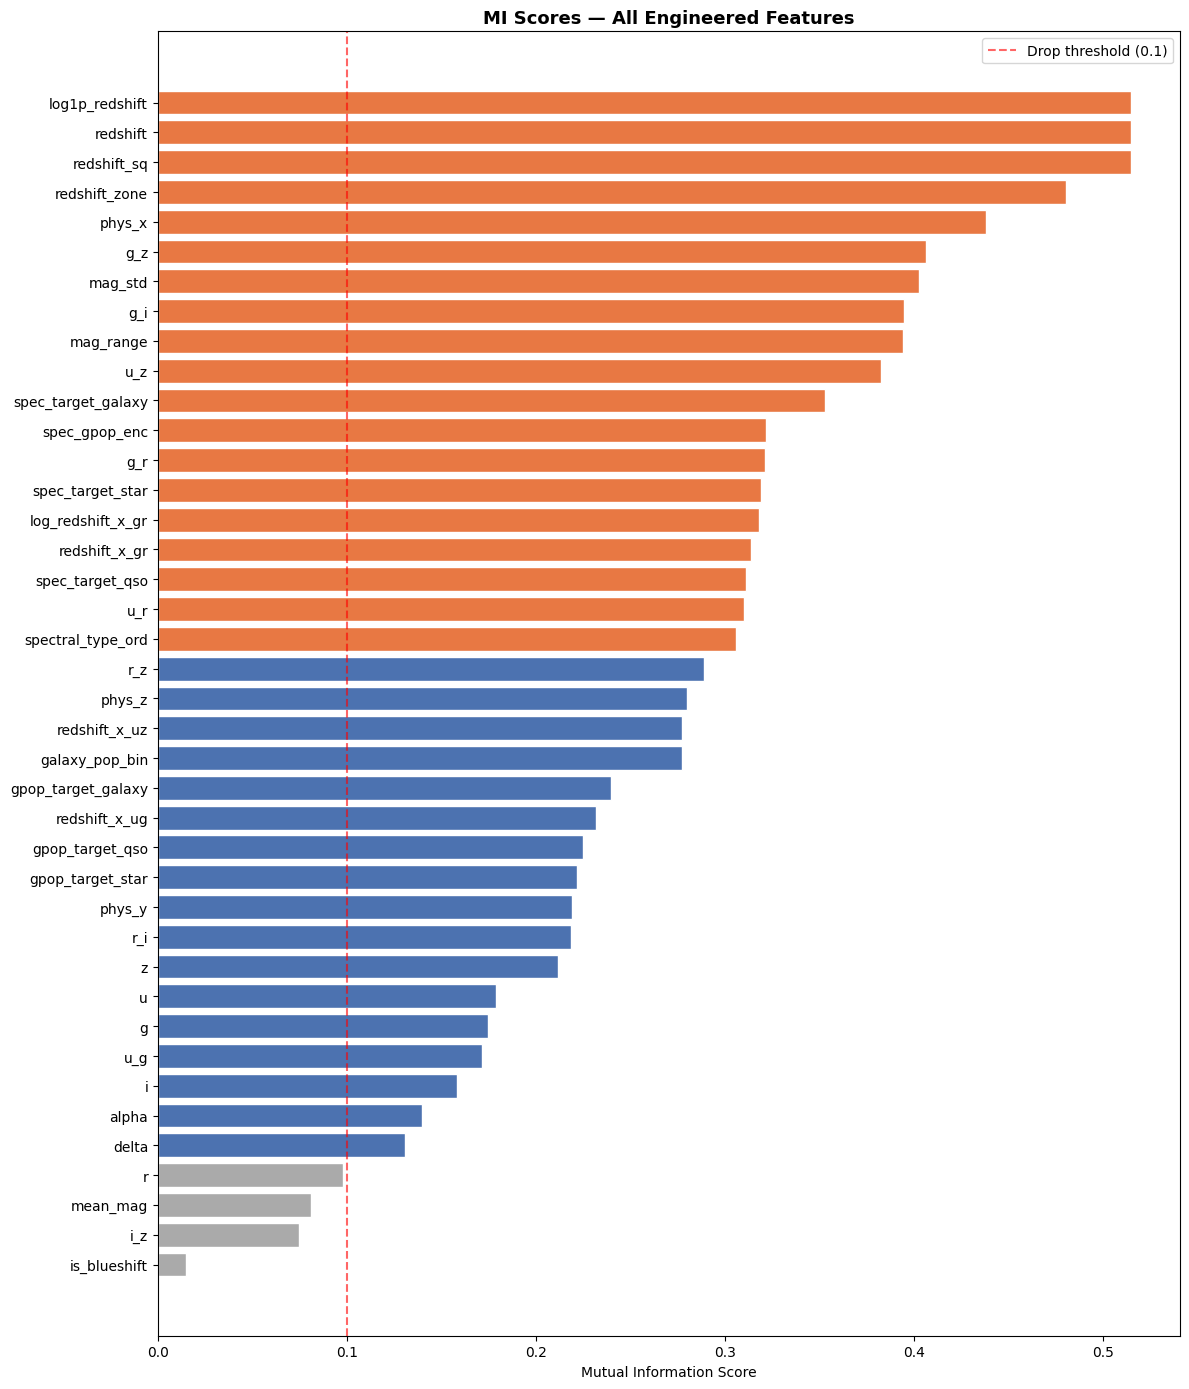

In [7]:
# Encode target for MI
le = LabelEncoder()
y_train = le.fit_transform(train['class'])

# Only check on kaggle train (has all features populated)
X_mi = train[ALL_FEATURE_COLS].fillna(-9999)  # temporary fill for MI

mi_scores = mutual_info_classif(X_mi, y_train, random_state=42)
mi_df = (
    pd.Series(mi_scores, index=ALL_FEATURE_COLS)
    .sort_values(ascending=False)
)

print('=== MI Scores — All Engineered Features ===')
print(mi_df.round(4).to_string())

# Plot
fig, ax = plt.subplots(figsize=(12, 14))
colors = ['#E87843' if v > 0.3 else '#4C72B0' if v > 0.1 else '#AAAAAA'
          for v in mi_df.values]
ax.barh(mi_df.index[::-1], mi_df.values[::-1], color=colors[::-1], edgecolor='white')
ax.axvline(0.1, color='red', linestyle='--', alpha=0.6, label='Drop threshold (0.1)')
ax.set_xlabel('Mutual Information Score')
ax.set_title('MI Scores — All Engineered Features', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Drop Low-MI Features & Finalize

In [8]:
# Drop anything under 0.05 MI — confirmed noise
MI_THRESHOLD = 0.05

features_to_drop = mi_df[mi_df < MI_THRESHOLD].index.tolist()
print(f'Features below MI threshold ({MI_THRESHOLD}):')
print(features_to_drop)

FINAL_FEATURES = [f for f in ALL_FEATURE_COLS if f not in features_to_drop]
print(f'\nFinal feature count: {len(FINAL_FEATURES)}')
print('\nFinal features:')
for f in FINAL_FEATURES:
    print(f'  {f:35s}  MI={mi_df.get(f, 0):.4f}')

Features below MI threshold (0.05):
['is_blueshift']

Final feature count: 39

Final features:
  alpha                                MI=0.1395
  delta                                MI=0.1307
  u                                    MI=0.1789
  g                                    MI=0.1746
  r                                    MI=0.0979
  i                                    MI=0.1582
  z                                    MI=0.2115
  redshift                             MI=0.5150
  log1p_redshift                       MI=0.5150
  redshift_sq                          MI=0.5147
  redshift_zone                        MI=0.4803
  u_g                                  MI=0.1713
  g_r                                  MI=0.3212
  r_i                                  MI=0.2183
  i_z                                  MI=0.0748
  u_r                                  MI=0.3102
  u_z                                  MI=0.3828
  g_i                                  MI=0.3949
  g_z                  

# Sanity Checks

In [9]:
# Check for any unexpected inf/nan in final features on kaggle train
print('=== NaN/Inf check — Kaggle Train ===')
for col in FINAL_FEATURES:
    n_nan = train[col].isna().sum()
    n_inf = np.isinf(train[col].replace([np.inf, -np.inf], np.nan).fillna(0)).sum()
    if n_nan > 0 or n_inf > 0:
        print(f'  {col}: {n_nan} NaN, {n_inf} Inf')
print('  (no output = all clean)')

print('\n=== NaN/Inf check — Test ===')
for col in FINAL_FEATURES:
    n_nan = test[col].isna().sum()
    n_inf = np.isinf(test[col].replace([np.inf, -np.inf], np.nan).fillna(0)).sum()
    if n_nan > 0 or n_inf > 0:
        print(f'  {col}: {n_nan} NaN, {n_inf} Inf')
print('  (no output = all clean)')

# Shape summary
print(f'\nFinal shapes:')
print(f'  train[FINAL_FEATURES]: {train[FINAL_FEATURES].shape}')
print(f'  test[FINAL_FEATURES] : {test[FINAL_FEATURES].shape}')
print(f'  train_augmented      : {train_augmented.shape}')

=== NaN/Inf check — Kaggle Train ===
  (no output = all clean)

=== NaN/Inf check — Test ===
  (no output = all clean)

Final shapes:
  train[FINAL_FEATURES]: (577347, 39)
  test[FINAL_FEATURES] : (247435, 39)
  train_augmented      : (677346, 46)


# Quick Distribution Check — New Features

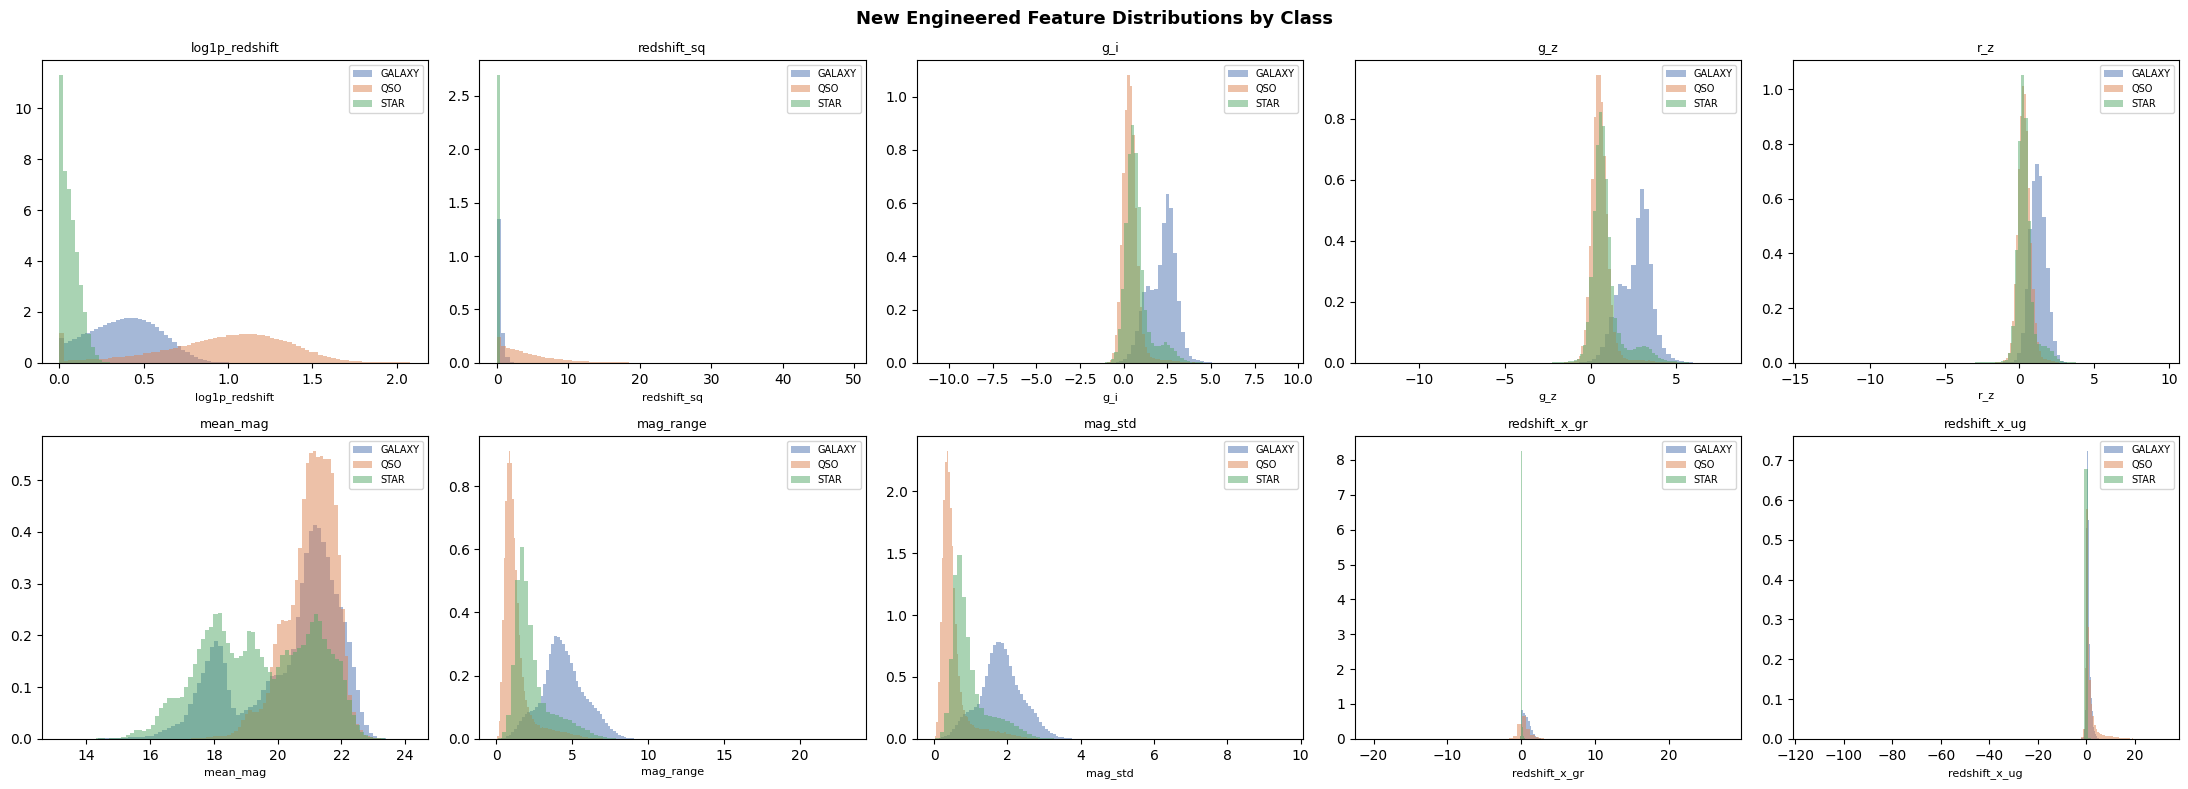

In [10]:
NEW_FEATURES_TO_PLOT = [
    'log1p_redshift', 'redshift_sq', 'g_i', 'g_z', 'r_z',
    'mean_mag', 'mag_range', 'mag_std',
    'redshift_x_gr', 'redshift_x_ug',
]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

for ax, col in zip(axes, NEW_FEATURES_TO_PLOT):
    for cls, clr in CLASS_COLORS.items():
        sub = train.loc[train['class'] == cls, col]
        ax.hist(sub, bins=80, alpha=0.5, color=clr, density=True, label=cls)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle('New Engineered Feature Distributions by Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# State for Modeling

In [11]:
# These are the objects you carry into the modeling phase

print('=== Objects ready for modeling ===')
print(f'  train            : {train.shape}  — kaggle train with all features')
print(f'  test             : {test.shape}   — kaggle test with all features')
print(f'  train_augmented  : {train_augmented.shape} — kaggle + original')
print(f'  FINAL_FEATURES   : {len(FINAL_FEATURES)} features')
print(f'  CLASS_ORDER      : {CLASS_ORDER}')
print()
print('Target encoding: le.classes_ =', le.classes_)
print()
print('NOTE: train_augmented has NaN in categorical-derived features')
print('      for original rows — LightGBM handles this natively.')
print()
print('FINAL_FEATURES list:')
print(FINAL_FEATURES)

=== Objects ready for modeling ===
  train            : (577347, 46)  — kaggle train with all features
  test             : (247435, 44)   — kaggle test with all features
  train_augmented  : (677346, 46) — kaggle + original
  FINAL_FEATURES   : 39 features
  CLASS_ORDER      : ['GALAXY', 'QSO', 'STAR']

Target encoding: le.classes_ = ['GALAXY' 'QSO' 'STAR']

NOTE: train_augmented has NaN in categorical-derived features
      for original rows — LightGBM handles this natively.

FINAL_FEATURES list:
['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'log1p_redshift', 'redshift_sq', 'redshift_zone', 'u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'u_z', 'g_i', 'g_z', 'r_z', 'mean_mag', 'mag_range', 'mag_std', 'redshift_x_gr', 'redshift_x_ug', 'redshift_x_uz', 'log_redshift_x_gr', 'phys_x', 'phys_y', 'phys_z', 'spectral_type_ord', 'galaxy_pop_bin', 'spec_gpop_enc', 'spec_target_galaxy', 'spec_target_qso', 'spec_target_star', 'gpop_target_galaxy', 'gpop_target_qso', 'gpop_target_star']
